In [22]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('..')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as patches

import IRSMicroLensing.IRSFunctions as IRSF
import IRSMicroLensing.IRSCaustics as IRSC
import VBMicrolensing

import csv

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['figure.titlesize'] = 20
plt.rcParams['figure.titleweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['figure.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['mathtext.fontset'] = 'cm'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [23]:
VBM = VBMicrolensing.VBMicrolensing() # Instance to VBMicroLensing

s1s = np.array([0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])
# 1, 1/0.9, 1/0.8, 1/0.7, 1/0.6, 1/0.5, 1/0.4, 1/0.3, 1/0.2
alpha1 = 0
q1s = np.array([1e-6, 3e-6, 1e-5, 3e-5, 1e-4, 3e-4, 1e-3])

print(f'{len(s1s) * len(q1s)} binary lens configurations will be calculated.')

56 binary lens configurations will be calculated.


In [4]:
with open('binary_attributes.csv', 'w') as file:
    writer = csv.writer(file)
    writer.writerow(['s1', 'q1', 'ang_width', 'thickness', 'y_plus', 'y_minus', 'num_r', 'num_theta'])

    for s1 in s1s:
        for q1 in q1s:
            if s1 == 1:
                continue
            print('-----------------------------')
            print(f's1 = {s1}, q1 = {q1}')
            # Defining binary lens attributes
            binary_lens_attributes = np.array([
                [0, 0, 1],
                [s1*np.cos(np.deg2rad(alpha1)), s1*np.sin(np.deg2rad(alpha1)), q1],
            ])

            # Rotation matrix for first planet
            first_planet_DCM = np.array([
                [np.cos(np.deg2rad(alpha1)), -np.sin(np.deg2rad(alpha1))],
                [np.sin(np.deg2rad(alpha1)), np.cos(np.deg2rad(alpha1))]
            ])

            # Binary offset
            delta1_rot = np.array([q1 / ((1 + q1) * (s1 + 1/s1)), 0]).reshape(-1, 1)
            delta1 = np.dot(first_planet_DCM, delta1_rot).reshape(2)
            print(f'Binary offset: {delta1}')

            # Correcting binary lens attributes
            binary_lens_attributes[:, :2] -= delta1

            # Map parameters
            pixels = 2000
            delta = 0.01

            ang_width, thickness, (y_plus, y_minus), cusp_points = IRSC.IRSCaustics.ang_width_thickness_calculator(binary_lens_attributes)
            num_r, num_theta = IRSC.IRSCaustics.num_ray_calculator(pixels, ang_width, delta, y_plus, y_minus)

            print(f'Angular width: {ang_width:.3e}, Thickness: {thickness:.3e}')
            print(f'Number of rays in r: {num_r}, Number of rays in theta: {num_theta}')
            print(f'Total number of rays: {num_r * num_theta:.4e}')

            writer.writerow([s1, q1, ang_width, thickness, y_plus, y_minus, num_r, num_theta])

-----------------------------
s1 = 0.2, q1 = 1e-06
Binary offset: [1.923075e-07 0.000000e+00]
Angular width: 4.500e-07, Thickness: 3.500e-07
Number of rays in r: 814152, Number of rays in theta: 203538
Total number of rays: 1.6571e+11
-----------------------------
s1 = 0.2, q1 = 3e-06
Binary offset: [5.76921346e-07 0.00000000e+00]
Angular width: 1.350e-06, Thickness: 1.050e-06
Number of rays in r: 814152, Number of rays in theta: 203538
Total number of rays: 1.6571e+11
-----------------------------
s1 = 0.2, q1 = 1e-05
Binary offset: [1.92305769e-06 0.00000000e+00]
Angular width: 4.500e-06, Thickness: 3.500e-06
Number of rays in r: 814152, Number of rays in theta: 203538
Total number of rays: 1.6571e+11
-----------------------------
s1 = 0.2, q1 = 3e-05
Binary offset: [5.7690577e-06 0.0000000e+00]
Angular width: 1.350e-05, Thickness: 1.050e-05
Number of rays in r: 814152, Number of rays in theta: 203538
Total number of rays: 1.6571e+11
-----------------------------
s1 = 0.2, q1 = 0.000

In [52]:
s1_str = '0.2'
s1 = eval(s1_str)

q1 = 1e-3

binary_lens_attributes = np.array([
    [0, 0, 1],
    [s1*np.cos(np.deg2rad(alpha1)), s1*np.sin(np.deg2rad(alpha1)), q1],
])

# Rotation matrix for first planet
first_planet_DCM = np.array([
    [np.cos(np.deg2rad(alpha1)), -np.sin(np.deg2rad(alpha1))],
    [np.sin(np.deg2rad(alpha1)), np.cos(np.deg2rad(alpha1))]
])

# Binary offset
delta1_rot = np.array([q1 / ((1 + q1) * (s1 + 1/s1)), 0]).reshape(-1, 1)
delta1 = np.dot(first_planet_DCM, delta1_rot).reshape(2)
print(f'Binary offset: {delta1}')

# Correcting binary lens attributes
binary_lens_attributes[:, :2] -= delta1

# Calculating center of mass of lenses
center_of_mass = np.average(binary_lens_attributes[:, :2], axis=0, weights=binary_lens_attributes[:, 2])
print(f'Center of mass: {center_of_mass}')

pixels = 2000
delta = 0.001

ang_width, thickness, (y_plus, y_minus), cusp_points = IRSC.IRSCaustics.ang_width_thickness_calculator(binary_lens_attributes, cm_offset='auto', cm_translation=delta1)
num_r, num_theta = IRSC.IRSCaustics.num_ray_calculator(pixels, ang_width, delta, y_plus, y_minus)

print(f'Angular width: {ang_width}, Thickness: {thickness}')
print(f'y_plus: {y_plus}, y_minus: {y_minus}')
print(f'Number of rays in r: {num_r}, Number of rays in theta: {num_theta}')

binary_lens_parameters = {
    'pixels': 1000,
    'ang_width': 5 * ang_width,
    'thickness': thickness,
    'y_plus': y_plus,
    'y_minus': y_minus,
    'lens_att': binary_lens_attributes.tolist(),
    'num_theta': 5000,
    'num_r': 20000
}

sim = IRSC.IRSCaustics(annulus_param_dict=binary_lens_parameters)
magnifications = sim.series_calculate(cm_offset='auto')

Binary offset: [0.00019212 0.        ]
Center of mass: [7.68462307e-06 0.00000000e+00]
Angular width: 0.0004815376930761546, Thickness: 0.00037454842498807484
y_plus: 1.0001872917483092, y_minus: -0.9998127433233212
Number of rays in r: 8141508, Number of rays in theta: 2035377


100%|██████████| 500/500 [00:03<00:00, 141.73it/s]

---------------------
Total time: 3.539 seconds



/Users/saividyud/Documents/GitHub/NBLens/Unity Analysis/../IRSMicroLensing/IRSCaustics.py:685: RuntimeWarning: divide by zero encountered in log10
  self.magnifications_log = np.log10(self.magnifications)


Plotting magnification map: 0.018 seconds
[-5.32266878e-05  0.00000000e+00]
[0.00012038 0.        ]
[0.00000000e+00 8.22172932e-05]
[ 0.00000000e+00 -8.22172932e-05]


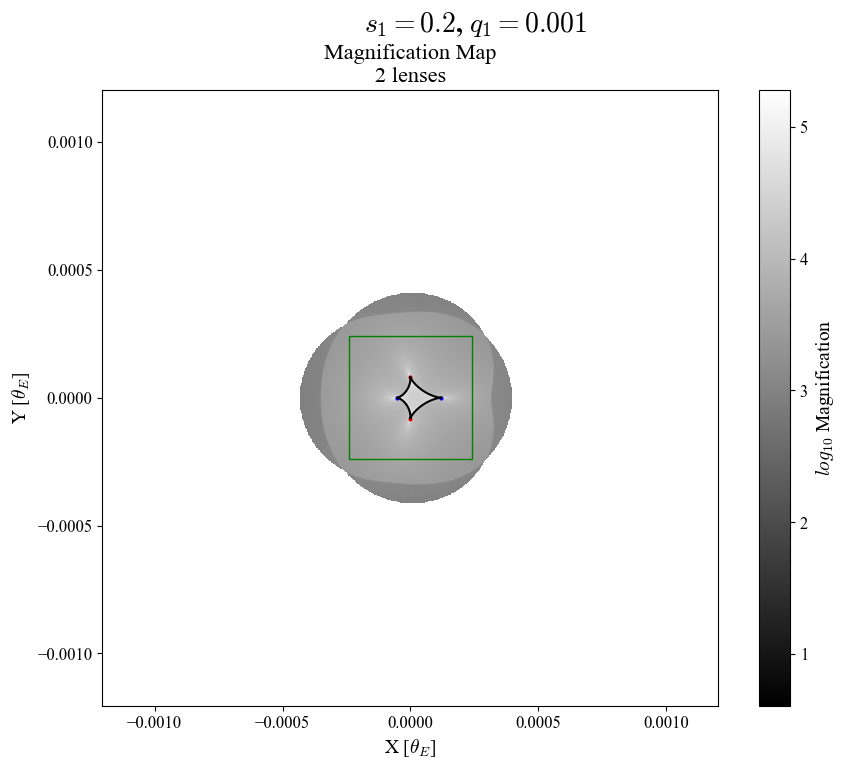

In [53]:
sim.plot()

for i, points in enumerate(cusp_points[0]):
    print(points)
    if i < 2:
        sim.ax_c.plot(*(points), 'bo', markersize=2)
    else:
        sim.ax_c.plot(*(points), 'ro', markersize=2)

map_patch = patches.Rectangle(
    xy=(-ang_width/2, -ang_width/2),
    width=ang_width,
    height=ang_width,
    linewidth=1,
    edgecolor='green',
    facecolor='none'
)

sim.ax_c.add_patch(map_patch)
sim.fig_c.suptitle(f'$s_1 = {s1_str}$, $q_1 = {q1}$')

parameters = [0, 0, 1,
                s1, 0, q1]

VBM.SetLensGeometry(parameters)
caustics = VBM.Multicaustics()

for caus in caustics:
    sim.ax_c.plot(caus[0] - delta1[0], caus[1] - delta1[1], 'k')

plt.show()

In [211]:
s1_str = '1/0.2'
s1 = eval(s1_str)

q1 = 1e-3

binary_lens_attributes = np.array([
    [0, 0, 1],
    [s1*np.cos(np.deg2rad(alpha1)), s1*np.sin(np.deg2rad(alpha1)), q1],
])

# Rotation matrix for first planet
first_planet_DCM = np.array([
    [np.cos(np.deg2rad(alpha1)), -np.sin(np.deg2rad(alpha1))],
    [np.sin(np.deg2rad(alpha1)), np.cos(np.deg2rad(alpha1))]
])

# Binary offset
delta1_rot = np.array([q1 / ((1 + q1) * (s1 + 1/s1)), 0]).reshape(-1, 1)
delta1 = np.dot(first_planet_DCM, delta1_rot).reshape(2)
print(f'Binary offset: {delta1}')

# Correcting binary lens attributes
binary_lens_attributes[:, :2] -= delta1

# Calculating center of mass of lenses
center_of_mass = np.average(binary_lens_attributes[:, :2], axis=0, weights=binary_lens_attributes[:, 2])
print(f'Center of mass: {center_of_mass}')

pixels = 2000
delta = 0.001

ang_width, thickness, (y_plus, y_minus), cusp_points = IRSC.IRSCaustics.ang_width_thickness_calculator(binary_lens_attributes, cm_offset='auto', cm_translation=delta1)
num_r, num_theta = IRSC.IRSCaustics.num_ray_calculator(pixels, ang_width, delta, y_plus, y_minus)

print(f'Angular width: {ang_width}, Thickness: {thickness}')
print(f'y_plus: {y_plus}, y_minus: {y_minus}')
print(f'Number of rays in r: {num_r}, Number of rays in theta: {num_theta}')

diff_y_plus = y_plus + 0.001
diff_y_minus = y_minus + 0.001
diff_thickness = diff_y_plus + diff_y_minus

print(diff_y_plus, diff_y_minus, diff_thickness)

binary_lens_parameters = {
    'pixels': 1000,
    'ang_width': 2 * ang_width,
    'thickness': diff_thickness,
    'y_plus': diff_y_plus,
    'y_minus': diff_y_minus,
    'lens_att': binary_lens_attributes.tolist(),
    'num_theta': 5000,
    'num_r': 20000
}

sim = IRSC.IRSCaustics(annulus_param_dict=binary_lens_parameters)
magnifications = sim.series_calculate(cm_offset='auto')

Binary offset: [0.00019212 0.        ]
Center of mass: [0.00480289 0.        ]
Angular width: 0.0004815376930761557, Thickness: 0.00037454842498807484
y_plus: 1.0001872917483092, y_minus: -0.9998127433233212
Number of rays in r: 8141508, Number of rays in theta: 2035377
1.0011872917483091 -0.9988127433233212 0.0023745484249879656


100%|██████████| 500/500 [00:03<00:00, 137.43it/s]

---------------------
Total time: 3.65 seconds


Plotting magnification map: 0.04 seconds
[-5.32266878e-05  0.00000000e+00]
[0.00012038 0.        ]
[0.00000000e+00 8.22172932e-05]
[ 0.00000000e+00 -8.22172932e-05]


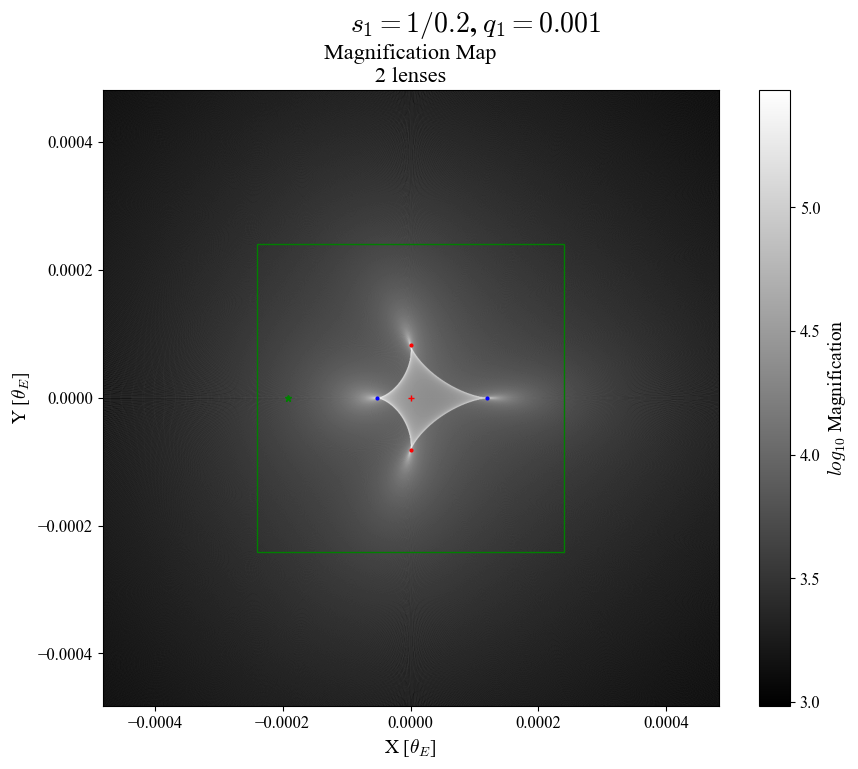

In [212]:
sim.plot()

for i, points in enumerate(cusp_points[0]):
    print(points)
    if i < 2:
        sim.ax_c.plot(points[0], points[1], 'bo', markersize=2)
    else:
        sim.ax_c.plot(*(points), 'ro', markersize=2)

sim.ax_c.plot(binary_lens_attributes[0, 0], binary_lens_attributes[0, 1], color='g', marker='*', markersize=5)
sim.ax_c.plot(0, 0, color='r', marker='+', markersize=5)
sim.ax_c.plot(center_of_mass[0], center_of_mass[1], color='k', marker='x', markersize=5)

map_patch = patches.Rectangle(
    xy=(-ang_width/2, -ang_width/2),
    width=ang_width,
    height=ang_width,
    linewidth=1,
    edgecolor='green',
    facecolor='none'
)

sim.ax_c.add_patch(map_patch)
sim.fig_c.suptitle(f'$s_1 = {s1_str}$, $q_1 = {q1}$')

parameters = [0, 0, 1,
                s1, 0, q1]

VBM.SetLensGeometry(parameters)
caustics = VBM.Multicaustics()

# for caus in caustics:
#     sim.ax_c.plot(caus[0] - delta1[0], caus[1] - delta1[1], 'k')

plt.show()

In [7]:
file = pd.read_csv('binary_attributes.csv')

# print(file)

row = file[(file['s1'] == 0.5) & (file['q1'] == 1e-4)].iloc[0]
print(row)

row = np.array(row)

s1 = row[0]
q1 = row[1]
ang_width = row[2]
thickness = row[3]
y_plus = row[4]
y_minus = row[5]
num_r = int(row[6])
num_theta = int(row[7])

print(s1, q1, ang_width, thickness, y_plus, y_minus, num_r, num_theta)

s1                0.500000
q1                0.000100
ang_width         0.000600
thickness         0.000467
y_plus            1.000233
y_minus          -0.999767
num_r        814152.000000
num_theta    203538.000000
Name: 25, dtype: float64
0.5 0.0001 0.0006000199980002 0.0004667060303767 1.0002333802420027 -0.999766674211626 814152 203538
